## Assignment 2: Language Model

Name: Muhammad Fahad Waqar<br>
Student No: st125981

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import re
from collections import Counter

import math
import numpy as np
import pandas as pd
from tqdm import tqdm
import os
import urllib.request
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
SEED = 1234
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True

# Checking for GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')

Using device: cuda
PyTorch version: 2.5.1


In [ ]:
class BasicEnglishTokenizer:
    def __call__(self, text):
        # Convert to lowercase and split by whitespace/punctuation
        text = text.lower()
        # Add spaces around punctuation
        text = re.sub(r"([.!?,;:])", r" \1 ", text)
        # Split on whitespace
        tokens = text.split()
        return tokens

class Vocab:
    def __init__(self, tokens, min_freq=1, specials=None):
        self.specials = specials or []
        self.min_freq = min_freq
        
        # Count token frequencies
        counter = Counter(tokens)
        
        self.itos = self.specials.copy()
        for token, freq in counter.items():
            if freq >= min_freq and token not in self.itos:
                self.itos.append(token)
        
        # Create reverse mapping
        self.stoi = {token: idx for idx, token in enumerate(self.itos)}
        self.default_index = self.stoi.get('<unk>', 0)
    
    def __len__(self):
        return len(self.itos)
    
    def __getitem__(self, token):
        return self.stoi.get(token, self.default_index)
    
    def get_itos(self):
        return self.itos
    
    def set_default_index(self, index):
        self.default_index = index

# Initialize tokenizer
tokenizer = BasicEnglishTokenizer()

### 1.2 Load Harry Potter Dataset

In [48]:
# Load Harry Potter books from the data folder
def load_harry_potter_books():
    data_dir = 'data'
    
    # List of Harry Potter book files
    book_files = [
        '01 Harry Potter and the Sorcerers Stone.txt',
        '02 Harry Potter and the Chamber of Secrets.txt',
        '03 Harry Potter and the Prisoner of Azkaban.txt',
        '04 Harry Potter and the Goblet of Fire.txt',
        '05 Harry Potter and the Order of the Phoenix.txt',
        '06 Harry Potter and the Half-Blood Prince.txt',
        '07 Harry Potter and the Deathly Hallows.txt'
    ]
    
    all_text = []
    
    print("Loading Harry Potter books...")
    
    for book_file in book_files:
        file_path = os.path.join(data_dir, book_file)
        
        if os.path.exists(file_path):
            with open(file_path, 'r', encoding='utf-8') as f:
                book_text = f.read()
                all_text.append(book_text)
                
            print(f"Loaded: {book_file}")
            print(f"Characters: {len(book_text):,}")
        else:
            print(f"Not found: {book_file}")
        
    # Combine all books into one text corpus
    combined_text = '\n\n'.join(all_text)
    
    print(f"\nTotal books loaded: {len(all_text)}")
    print(f"Combined corpus size: {len(combined_text):,} characters")
    
    return combined_text

# Load all Harry Potter books
text = load_harry_potter_books()

Loading Harry Potter books...
Loaded: 01 Harry Potter and the Sorcerers Stone.txt
Characters: 439,478
Loaded: 02 Harry Potter and the Chamber of Secrets.txt
Characters: 492,297
Loaded: 03 Harry Potter and the Prisoner of Azkaban.txt
Characters: 625,735
Loaded: 04 Harry Potter and the Goblet of Fire.txt
Characters: 1,100,515
Loaded: 05 Harry Potter and the Order of the Phoenix.txt
Characters: 1,499,410
Loaded: 06 Harry Potter and the Half-Blood Prince.txt
Characters: 987,992
Loaded: 07 Harry Potter and the Deathly Hallows.txt
Characters: 1,140,011

Total books loaded: 7
Combined corpus size: 6,285,450 characters


In [34]:
# Display dataset statistics
print(f"Dataset Statistics:")
print(f"- Total characters: {len(text):,}")
print(f"- Total words: {len(text.split()):,}")
print(f"- Unique characters: {len(set(text))}")
print(f"\nFirst 500 characters:")
print(text[:500])

Dataset Statistics:
- Total characters: 6,285,450
- Total words: 1,101,476
- Unique characters: 106

First 500 characters:
M r. and Mrs. Dursley, of number four, Privet Drive, were proud to say that they were perfectly normal, thank you very much. They were the last people you’d expect to be involved in anything strange or mysterious, because they just didn’t hold with such nonsense.

Mr. Dursley was the director of a firm called Grunnings, which made drills. He was a big, beefy man with hardly any neck, although he did have a very large mustache. Mrs. Dursley was thin and blonde and had nearly twice the usual amoun


---

## Task 2.1: Data Preprocessing

### Preprocessing Pipeline

The preprocessing pipeline consists of the following steps:

1. **Text Cleaning:** Remove excessive whitespace and normalize line breaks
2. **Tokenization:** Convert text into tokens (words) using basic_english tokenizer
3. **Vocabulary Building:** Create a mapping between tokens and numerical indices
4. **Special Tokens:** Add `<unk>` (unknown) and `<eos>` (end of sentence) tokens
5. **Numericalization:** Convert tokens to numerical indices
6. **Sequence Creation:** Organize data into batches for efficient training

Each step is crucial for preparing the raw text into a format suitable for neural network training.

### Step 1: Text Cleaning

In [ ]:
def clean_text(text):
    # Replace multiple newlines with space
    text = re.sub(r'\n+', ' ', text)
    # Replace multiple spaces with single space
    text = re.sub(r'\s+', ' ', text)
    # Strip leading/trailing whitespace
    text = text.strip()
    return text

cleaned_text = clean_text(text)
print(f"Cleaned text length: {len(cleaned_text):,} characters")
print(f"Sample cleaned text:\n{cleaned_text[:300]}")

Cleaned text length: 6,244,417 characters
Sample cleaned text:
M r. and Mrs. Dursley, of number four, Privet Drive, were proud to say that they were perfectly normal, thank you very much. They were the last people you’d expect to be involved in anything strange or mysterious, because they just didn’t hold with such nonsense. Mr. Dursley was the director of a fi


### Step 2: Tokenization

Tokenization breaks text into individual tokens (words). We use the `basic_english` tokenizer from torchtext which:
- Splits on whitespace
- Handles punctuation
- Converts to lowercase

In [ ]:
# Tokenize the cleaned text
tokens = tokenizer(cleaned_text)

print(f"Total tokens: {len(tokens):,}")
print(f"First 50 tokens: {tokens[:50]}")
print(f"\nUnique tokens: {len(set(tokens)):,}")

Total tokens: 1,307,836
First 50 tokens: ['m', 'r', '.', 'and', 'mrs', '.', 'dursley', ',', 'of', 'number', 'four', ',', 'privet', 'drive', ',', 'were', 'proud', 'to', 'say', 'that', 'they', 'were', 'perfectly', 'normal', ',', 'thank', 'you', 'very', 'much', '.', 'they', 'were', 'the', 'last', 'people', 'you’d', 'expect', 'to', 'be', 'involved', 'in', 'anything', 'strange', 'or', 'mysterious', ',', 'because', 'they', 'just', 'didn’t']

Unique tokens: 33,707


### Step 3: Build Vocabulary

The vocabulary maps each unique token to a numerical index. We:
1. Build vocabulary from the tokenized text
2. Set minimum frequency threshold (min_freq=3) to filter rare words
3. Add special tokens: `<unk>` for unknown words, `<eos>` for end of sequence
4. Set default index to `<unk>` for out-of-vocabulary words

In [ ]:
vocab = Vocab(tokens, min_freq=3, specials=['<unk>', '<eos>'])

# Set default index for unknown tokens
vocab.set_default_index(vocab['<unk>'])

# Display vocabulary statistics
print(f"Vocabulary size: {len(vocab):,}")
print(f"\nSpecial tokens:")
print(f"  <unk> index: {vocab['<unk>']}")
print(f"  <eos> index: {vocab['<eos>']}")
print(f"\nFirst 20 tokens in vocabulary:")
print(vocab.get_itos()[:20])

Vocabulary size: 14,139

Special tokens:
  <unk> index: 0
  <eos> index: 1

First 20 tokens in vocabulary:
['<unk>', '<eos>', 'm', 'r', '.', 'and', 'mrs', 'dursley', ',', 'of', 'number', 'four', 'privet', 'drive', 'were', 'proud', 'to', 'say', 'that', 'they']


### Step 4: Numericalization and Data Preparation

Convert tokens to numerical indices and organize into batches:
1. Add `<eos>` token to mark sentence boundaries
2. Convert each token to its vocabulary index
3. Create tensor and reshape into batches for efficient training
4. Split data into train/validation/test sets (80%/10%/10%)

In [ ]:
def get_data(tokens, vocab, batch_size):
    # Add end-of-sequence token
    tokens_with_eos = tokens + ['<eos>']
    
    # Convert tokens to indices using vocabulary
    # If a token is not in vocab, it gets mapped to <unk>
    indices = [vocab[token] for token in tokens_with_eos]
    
    # Convert to PyTorch tensor
    data = torch.LongTensor(indices)
    
    # Calculate number of complete batches we can make
    num_batches = data.shape[0] // batch_size
    
    # Trim data to fit exactly into batches
    data = data[:num_batches * batch_size]
    
    # Reshape into [batch_size, num_batches]
    # Each row is a sequence, columns are time steps
    data = data.view(batch_size, num_batches)
    
    return data

# Set batch size
batch_size = 32

# Prepare the data
data = get_data(tokens, vocab, batch_size)

# Split into train/validation/test (80%/10%/10%)
total_batches = data.shape[1]
train_size = int(0.8 * total_batches)
valid_size = int(0.9 * total_batches)

train_data = data[:, :train_size]
valid_data = data[:, train_size:valid_size]
test_data = data[:, valid_size:]

print(f"Data shapes:")
print(f"  Train: {train_data.shape} (batch_size x sequence_length)")
print(f"  Validation: {valid_data.shape}")
print(f"  Test: {test_data.shape}")
print(f"\nTotal training tokens: {train_data.numel():,}")

Data shapes:
  Train: torch.Size([32, 32695]) (batch_size x sequence_length)
  Validation: torch.Size([32, 4087])
  Test: torch.Size([32, 4087])

Total training tokens: 1,046,240


---

## Task 2.2: Model Architecture and Training

### LSTM Language Model Architecture

1. **Embedding Layer:** Converts token indices to dense vector representations
2. **LSTM Layers:** Stacked LSTM layers capture sequential dependencies and context
3. **Dropout:** Regularization to prevent overfitting
4. **Output Layer:** Fully connected layer that projects LSTM outputs to vocabulary size

**Architecture Details:**
- **Input:** Token indices [batch_size, seq_len]
- **Embedding:** Maps each token to dense vector [batch_size, seq_len, emb_dim]
- **LSTM:** Processes sequences and maintains hidden state [batch_size, seq_len, hid_dim]
- **Output:** Predicts next token probability distribution [batch_size, seq_len, vocab_size]

In [ ]:
class LSTMLanguageModel(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, num_layers, dropout_rate):
        super().__init__()
        self.num_layers = num_layers
        self.hid_dim = hid_dim
        self.emb_dim = emb_dim
        
        # Embedding layer: maps token indices to dense vectors
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        
        # LSTM layers: processes sequences and maintains hidden state
        # batch_first=True means input/output tensors are (batch, seq, feature)
        self.lstm = nn.LSTM(emb_dim, hid_dim, num_layers=num_layers, 
                           dropout=dropout_rate, batch_first=True)
        
        # Dropout for regularization
        self.dropout = nn.Dropout(dropout_rate)
        
        # Output layer: projects LSTM output to vocabulary size
        self.fc = nn.Linear(hid_dim, vocab_size)
        
        # Initialize weights with small random values
        self.init_weights()
    
    def init_weights(self):
        init_range_emb = 0.1
        init_range_other = 1/math.sqrt(self.hid_dim)
        
        # Initialize embedding weights
        self.embedding.weight.data.uniform_(-init_range_emb, init_range_emb)
        
        # Initialize output layer weights and biases
        self.fc.weight.data.uniform_(-init_range_other, init_range_other)
        self.fc.bias.data.zero_()
        
        # Initialize LSTM weights for each layer
        for i in range(self.num_layers):
            # We: input-to-hidden weights
            self.lstm.all_weights[i][0] = torch.FloatTensor(
                self.emb_dim, self.hid_dim).uniform_(-init_range_other, init_range_other)
            # Wh: hidden-to-hidden weights
            self.lstm.all_weights[i][1] = torch.FloatTensor(
                self.hid_dim, self.hid_dim).uniform_(-init_range_other, init_range_other)
    
    def init_hidden(self, batch_size, device):
        hidden = torch.zeros(self.num_layers, batch_size, self.hid_dim).to(device)
        cell = torch.zeros(self.num_layers, batch_size, self.hid_dim).to(device)
        return hidden, cell
    
    def detach_hidden(self, hidden):
        hidden, cell = hidden
        hidden = hidden.detach()
        cell = cell.detach()
        return hidden, cell
    
    def forward(self, src, hidden):
        embedding = self.dropout(self.embedding(src))
        output, hidden = self.lstm(embedding, hidden)
        
        output = self.dropout(output)
        prediction = self.fc(output)
        
        return prediction, hidden

# Display model summary
print("LSTM Language Model Architecture:")
print("Input: Token indices [batch_size, seq_len]")
print("  ↓")
print("Embedding Layer: [batch_size, seq_len, emb_dim]")
print("  ↓")
print("LSTM Layers: [batch_size, seq_len, hid_dim]")
print("  ↓")
print("Output Layer: [batch_size, seq_len, vocab_size]")

LSTM Language Model Architecture:
Input: Token indices [batch_size, seq_len]
  ↓
Embedding Layer: [batch_size, seq_len, emb_dim]
  ↓
LSTM Layers: [batch_size, seq_len, hid_dim]
  ↓
Output Layer: [batch_size, seq_len, vocab_size]


### Model Hyperparameters and Instantiation

We define hyperparameters based on the AWD-LSTM paper but scaled for our dataset size.

In [ ]:
# Hyperparameters
vocab_size = len(vocab)         # Size of our vocabulary
emb_dim = 256                   # Embedding dimension (smaller for our dataset)
hid_dim = 512                   # Hidden dimension
num_layers = 2                  # Number of LSTM layers
dropout_rate = 0.5              # Dropout rate for regularization
lr = 0.001                      # Learning rate

# Instantiate model
model = LSTMLanguageModel(vocab_size, emb_dim, hid_dim, num_layers, dropout_rate).to(device)

# Setup optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

# Count parameters
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model Configuration:")
print(f"  Vocabulary size: {vocab_size:,}")
print(f"  Embedding dimension: {emb_dim}")
print(f"  Hidden dimension: {hid_dim}")
print(f"  Number of layers: {num_layers}")
print(f"  Dropout rate: {dropout_rate}")
print(f"  Learning rate: {lr}")
print(f"\nTotal trainable parameters: {num_params:,}")

Model Configuration:
  Vocabulary size: 14,139
  Embedding dimension: 256
  Hidden dimension: 512
  Number of layers: 2
  Dropout rate: 0.5
  Learning rate: 0.001

Total trainable parameters: 14,551,099


### Training and Evaluation Functions

The training process:
1. **Get Batch:** Extract source and target sequences (target is source shifted by 1)
2. **Forward Pass:** Feed source through model to get predictions
3. **Compute Loss:** Compare predictions with target using CrossEntropyLoss
4. **Backward Pass:** Compute gradients
5. **Gradient Clipping:** Prevent exploding gradients
6. **Update Weights:** Apply optimizer step

In [ ]:
def get_batch(data, seq_len, idx):
    src = data[:, idx:idx+seq_len]
    target = data[:, idx+1:idx+seq_len+1]  # Target is ahead of source by 1
    return src, target


def train(model, data, optimizer, criterion, batch_size, seq_len, clip, device):
    epoch_loss = 0
    model.train()
    
    # Drop batches that don't fit exactly into seq_len chunks
    num_batches = data.shape[-1]
    data = data[:, :num_batches - (num_batches - 1) % seq_len]
    num_batches = data.shape[-1]
    
    # Initialize hidden state at the start of epoch
    hidden = model.init_hidden(batch_size, device)
    
    # Iterate through data in chunks of seq_len
    for idx in tqdm(range(0, num_batches - 1, seq_len), desc='Training', leave=False):
        optimizer.zero_grad()
        
        # Detach hidden state to prevent backprop through entire history
        hidden = model.detach_hidden(hidden)
        
        # Get batch and move to device
        src, target = get_batch(data, seq_len, idx)
        src, target = src.to(device), target.to(device)
        batch_size = src.shape[0]
        
        # Forward pass
        prediction, hidden = model(src, hidden)
        
        # Reshape for loss computation
        prediction = prediction.reshape(batch_size * seq_len, -1)
        target = target.reshape(-1)
        
        # Compute loss
        loss = criterion(prediction, target)
        
        # Backward pass
        loss.backward()
        
        # Clip gradients to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        
        # Update weights
        optimizer.step()
        
        epoch_loss += loss.item() * seq_len
    
    return epoch_loss / num_batches


def evaluate(model, data, criterion, batch_size, seq_len, device):
    epoch_loss = 0
    model.eval()
    
    num_batches = data.shape[-1]
    data = data[:, :num_batches - (num_batches - 1) % seq_len]
    num_batches = data.shape[-1]
    
    hidden = model.init_hidden(batch_size, device)
    
    with torch.no_grad():
        for idx in range(0, num_batches - 1, seq_len):
            hidden = model.detach_hidden(hidden)
            
            src, target = get_batch(data, seq_len, idx)
            src, target = src.to(device), target.to(device)
            batch_size = src.shape[0]
            
            prediction, hidden = model(src, hidden)
            prediction = prediction.reshape(batch_size * seq_len, -1)
            target = target.reshape(-1)
            
            loss = criterion(prediction, target)
            epoch_loss += loss.item() * seq_len
    
    return epoch_loss / num_batches

In [42]:
# Training hyperparameters
n_epochs = 25         # Number of training epochs
seq_len = 30          # Sequence length for training
clip = 0.25           # Gradient clipping threshold

# Learning rate scheduler - reduces LR when validation loss plateaus
lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=2)

# Track best validation loss for model checkpointing
best_valid_loss = float('inf')

# Lists to store training history
train_losses = []
valid_losses = []

print("Starting training...")

for epoch in range(n_epochs):
    # Train for one epoch
    train_loss = train(model, train_data, optimizer, criterion, 
                      batch_size, seq_len, clip, device)
    
    # Evaluate on validation set
    valid_loss = evaluate(model, valid_data, criterion, batch_size, 
                         seq_len, device)
    
    # Update learning rate based on validation loss
    lr_scheduler.step(valid_loss)
    
    # Save model if validation loss improved
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'best_harry_potter_lm.pt')
    
    # Store losses for plotting
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    
    # Calculate perplexity (exp(loss))
    train_ppl = math.exp(train_loss)
    valid_ppl = math.exp(valid_loss)
    
    # Print progress
    print(f'Epoch {epoch+1:02d}/{n_epochs}:')
    print(f'  Train Loss: {train_loss:.4f} | Train Perplexity: {train_ppl:7.3f}')
    print(f'  Valid Loss: {valid_loss:.4f} | Valid Perplexity: {valid_ppl:7.3f}')

print("Training completed!")
print(f"Best validation loss: {best_valid_loss:.4f}")

Starting training...


Epoch 01/25:
  Train Loss: 5.8968 | Train Perplexity: 363.862
  Valid Loss: 5.2713 | Valid Perplexity: 194.668


Epoch 02/25:
  Train Loss: 5.1777 | Train Perplexity: 177.268
  Valid Loss: 4.9770 | Valid Perplexity: 145.045


Epoch 03/25:
  Train Loss: 4.9394 | Train Perplexity: 139.687
  Valid Loss: 4.8308 | Valid Perplexity: 125.309


Epoch 04/25:
  Train Loss: 4.7847 | Train Perplexity: 119.669
  Valid Loss: 4.7344 | Valid Perplexity: 113.796


...

Epoch 21/25:
  Train Loss: 3.9227 | Train Perplexity:  50.536
  Valid Loss: 4.5081 | Valid Perplexity:  90.747


Epoch 22/25:
  Train Loss: 3.9081 | Train Perplexity:  49.804
  Valid Loss: 4.5099 | Valid Perplexity:  90.909


Epoch 23/25:
  Train Loss: 3.8976 | Train Perplexity:  49.285
  Valid Loss: 4.5114 | Valid Perplexity:  91.051


Epoch 24/25:
  Train Loss: 3.8880 | Train Perplexity:  48.815
  Valid Loss: 4.5108 | Valid Perplexity:  90.999


Epoch 25/25:
  Train Loss: 3.8786 | Train Perplexity:  48.355
  Valid Loss: 4.5096 | Valid Perplexity:  90.883
Training completed!
Best validation loss: 4.5081


### Visualize Training Progress

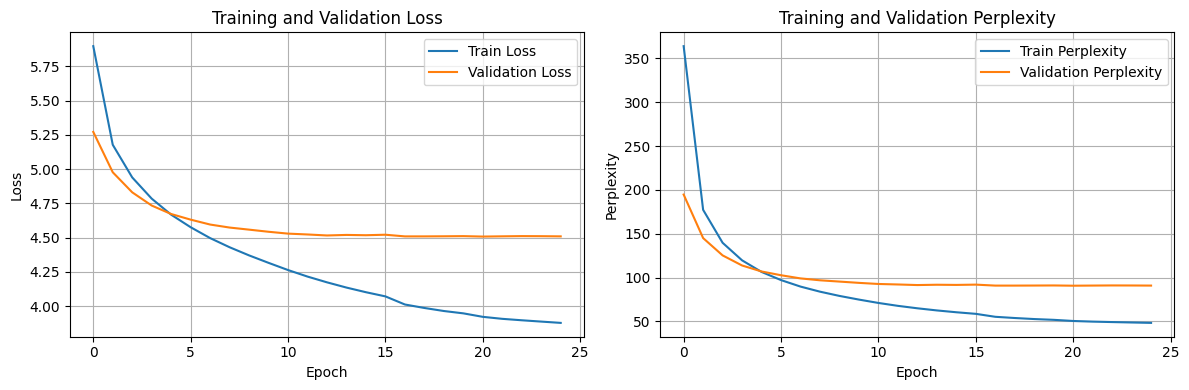

In [43]:
# Plot training and validation loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(valid_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
train_ppls = [math.exp(loss) for loss in train_losses]
valid_ppls = [math.exp(loss) for loss in valid_losses]
plt.plot(train_ppls, label='Train Perplexity')
plt.plot(valid_ppls, label='Validation Perplexity')
plt.xlabel('Epoch')
plt.ylabel('Perplexity')
plt.title('Training and Validation Perplexity')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_progress.png', dpi=150, bbox_inches='tight')
plt.show()

### Test Model Performance

In [44]:
# Load best model
model.load_state_dict(torch.load('best_harry_potter_lm.pt', map_location=device))

# Evaluate on test set
test_loss = evaluate(model, test_data, criterion, batch_size, seq_len, device)
test_ppl = math.exp(test_loss)

print("Test Set Performance:")
print(f"  Test Loss: {test_loss:.4f}")
print(f"  Test Perplexity: {test_ppl:.3f}")

C:\Users\mfaha\AppData\Local\Temp\ipykernel_5680\2827355514.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_harry_potter_lm.pt', m

Test Set Performance:
  Test Loss: 4.5058
  Test Perplexity: 90.545


---

## Text Generation

### Generation Function

The generation process:
1. **Tokenize prompt:** Convert input text to tokens
2. **Encode:** Map tokens to vocabulary indices
3. **Initialize hidden state:** Start with zero hidden state
4. **Autoregressive generation:** For each step:
   - Feed current sequence through model
   - Get probability distribution for next token
   - Apply temperature scaling to control randomness
   - Sample next token from distribution
   - Add token to sequence and repeat
5. **Stop conditions:** Stop when `<eos>` token is generated or max length reached

In [45]:
def generate(prompt, max_seq_len, temperature, model, tokenizer, vocab, device, seed=None):
    if seed is not None:
        torch.manual_seed(seed)
    
    model.eval()
    
    # Tokenize and encode the prompt
    tokens = tokenizer(prompt)
    indices = [vocab[t] for t in tokens]
    
    # Initialize hidden state
    batch_size = 1
    hidden = model.init_hidden(batch_size, device)
    
    with torch.no_grad():
        for i in range(max_seq_len):
            # Convert current sequence to tensor
            src = torch.LongTensor([indices]).to(device)
            
            # Get model prediction
            prediction, hidden = model(src, hidden)
            
            # Get probability distribution for last token
            # prediction[:, -1] extracts logits for the next token
            # Temperature scaling: higher temp = more random, lower = more deterministic
            probs = torch.softmax(prediction[:, -1] / temperature, dim=-1)
            
            # Sample next token from distribution
            prediction = torch.multinomial(probs, num_samples=1).item()
            
            # Skip <unk> tokens - resample if we get one
            while prediction == vocab['<unk>']:
                prediction = torch.multinomial(probs, num_samples=1).item()
            
            # Stop if we generate <eos>
            if prediction == vocab['<eos>']:
                break
            
            # Add predicted token to sequence (autoregressive)
            indices.append(prediction)
    
    # Convert indices back to tokens
    itos = vocab.get_itos()
    tokens = [itos[i] for i in indices]
    
    return tokens

### Testing Text Generation

- **Lower temperature (0.5-0.7):** More conservative, predictable text
- **Higher temperature (0.9-1.2):** More creative, diverse text

In [46]:
# Test generation with different prompts
prompts = [
    "Harry Potter is",
    "The boy who",
    "Mr. Dursley was"
]

max_seq_len = 50
temperatures = [0.5, 0.7, 1.0]
seed = 42

print("Text Generation Samples:")

for prompt in prompts:
    print(f"\nPrompt: '{prompt}'")
    print("-" * 80)
    
    for temperature in temperatures:
        generation = generate(prompt, max_seq_len, temperature, model, 
                            tokenizer, vocab, device, seed)
        generated_text = ' '.join(generation)
        
        print(f"\nTemperature {temperature}:")
        print(generated_text)

Text Generation Samples:

Prompt: 'Harry Potter is'
--------------------------------------------------------------------------------

Temperature 0.5:
harry potter is going to be able to keep a bit of the daily prophet . and then , if you are , i think we were going to be able to find out how to find it . i mean , he was in a book , but i think she could

Temperature 0.7:
harry potter is going to be a good idea of the night , or that it would have been to be judged , and we all know about the past of that graveyard . ” “its right , ” murmured harry . “harry , i am , ” said harry , as harry

Temperature 1.0:
harry potter is going to become a good account of the night since you kept it to detention and convince . two . the news will hear him an power in the past of that graveyard . beneath the way in the cabinet of ten minutes breakfast , they could do any of

Prompt: 'The boy who'
--------------------------------------------------------------------------------

Temperature 0.5:
the boy 

In [ ]:
# Saving the model and vocabulary
import pickle

# Create model directory
os.makedirs('app/models', exist_ok=True)

# Save model weights
torch.save(model.state_dict(), 'app/models/best_harry_potter_lm.pt')

# Save vocabulary
with open('app/models/vocab.pkl', 'wb') as f:
    pickle.dump(vocab, f)

# Save model configuration
config = {
    'vocab_size': vocab_size,
    'emb_dim': emb_dim,
    'hid_dim': hid_dim,
    'num_layers': num_layers,
    'dropout_rate': dropout_rate
}

with open('app/models/config.pkl', 'wb') as f:
    pickle.dump(config, f)

print("Model and vocabulary saved successfully!")
print(f"  Model: app/models/best_harry_potter_lm.pt")
print(f"  Vocabulary: app/models/vocab.pkl")
print(f"  Config: app/models/config.pkl")

Model and vocabulary saved successfully!
  Model: app/models/best_harry_potter_lm.pt
  Vocabulary: app/models/vocab.pkl
  Config: app/models/config.pkl
